In [1]:
# Cell 1 - Setup, Styling, and Data Ingestion
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, brier_score_loss, confusion_matrix
from sklearn.calibration import calibration_curve

# --- PUBLICATION STYLING ---
plt.style.use('default')
sns.set_context("paper", font_scale=1.5)
sns.set_style("ticks")
# Define a professional, colorblind-friendly palette
COLORS = {'x10': '#3498db', 'x20': '#e74c3c', 'fused': '#2ecc71', 'grid': '#e0e0e0'}
DPI = 300

print("="*80)
print("PREPARING DATA FOR PUBLICATION VISUALIZATIONS")
print("="*80)

# Load the saved patient data
RESULTS_PATH = Path("./5 Class Evaluation Results")

with open(RESULTS_PATH / 'x10_patient_metrics_mean.json', 'r') as f:
    x10_data = json.load(f)
with open(RESULTS_PATH / 'x20_patient_metrics_mean.json', 'r') as f:
    x20_data = json.load(f)

# Align Data by Patient
x10_dict = {p: prob for p, prob in zip(x10_data['patient_names'], x10_data['patient_probabilities'])}
x20_dict = {p: prob for p, prob in zip(x20_data['patient_names'], x20_data['patient_probabilities'])}
labels_dict = {p: lbl for p, lbl in zip(x10_data['patient_names'], x10_data['patient_labels'])}

p_x10, p_x20_cal, y_true = [], [], []

# Calibrate and Align
for p_name in x10_dict.keys():
    if p_name in x20_dict:
        prob10 = x10_dict[p_name]
        prob20 = x20_dict[p_name]
        
        # x20 Calibration logic
        if prob20 < 0.8351:
            cal20 = prob20 * (0.5 / 0.8351)
        else:
            cal20 = 0.5 + ((prob20 - 0.8351) * (0.5 / (1.0 - 0.8351)))
            
        p_x10.append(prob10)
        p_x20_cal.append(cal20)
        y_true.append(labels_dict[p_name])

# Arrays for plotting
y_true = np.array(y_true)
probs_x10 = np.array(p_x10)
probs_x20 = np.array(p_x20_cal)

# Calculate the Golden Model Fused Probabilities (w=0.20)
CLINICAL_WEIGHT = 0.20
probs_fused = (CLINICAL_WEIGHT * probs_x10) + ((1.0 - CLINICAL_WEIGHT) * probs_x20)

print(f"✓ Data loaded and fused for {len(y_true)} patients.")
print("✓ Ready to generate figures.")

PREPARING DATA FOR PUBLICATION VISUALIZATIONS
✓ Data loaded and fused for 67 patients.
✓ Ready to generate figures.


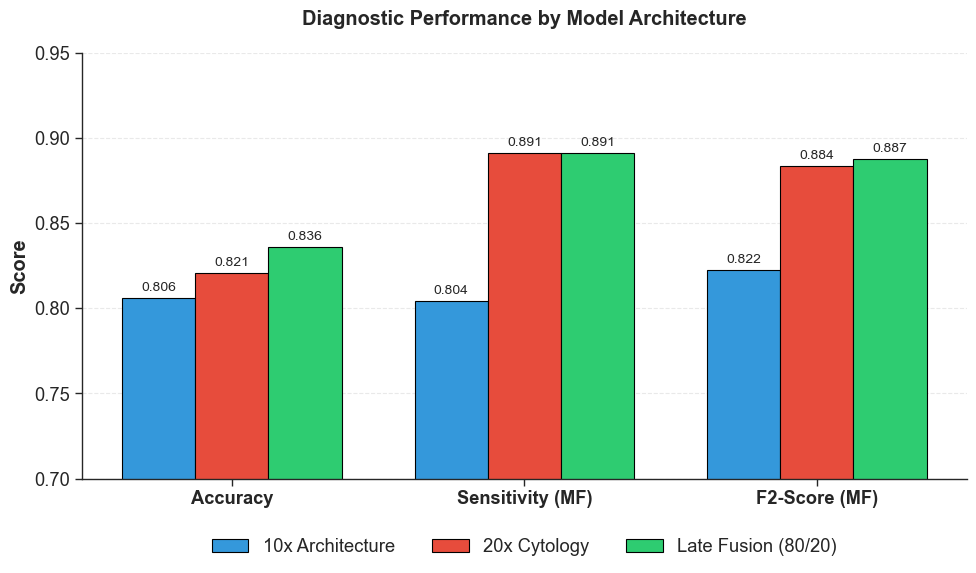

In [2]:
# Cell 2 - Comparative Metrics Bar Chart
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# 1. Calculate hard metrics
def get_metrics(y, p):
    preds = (p > 0.5).astype(int)
    acc = accuracy_score(y, preds)
    _, rec, f2, _ = precision_recall_fscore_support(y, preds, average=None, labels=[0,1], beta=2.0, zero_division=0)
    return [acc, rec[0], f2[0]] # [Accuracy, Sensitivity(MF), F2(MF)]

m_x10 = get_metrics(y_true, probs_x10)
m_x20 = get_metrics(y_true, probs_x20)
m_fused = get_metrics(y_true, probs_fused)

# 2. Setup the plot
labels = ['Accuracy', 'Sensitivity (MF)', 'F2-Score (MF)']
x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width, m_x10, width, label='10x Architecture', color=COLORS['x10'], edgecolor='black')
rects2 = ax.bar(x, m_x20, width, label='20x Cytology', color=COLORS['x20'], edgecolor='black')
rects3 = ax.bar(x + width, m_fused, width, label='Late Fusion (80/20)', color=COLORS['fused'], edgecolor='black')

# 3. Formatting
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Diagnostic Performance by Model Architecture', fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontweight='bold')
ax.set_ylim(0.70, 0.95)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=False)
ax.grid(axis='y', linestyle='--', alpha=0.7, color=COLORS['grid'])

# Add value labels on top of bars
for rects in [rects1, rects2, rects3]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, rotation=0)

sns.despine()
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'Fig1_Comparative_Metrics.png', dpi=DPI, bbox_inches='tight')
plt.show()

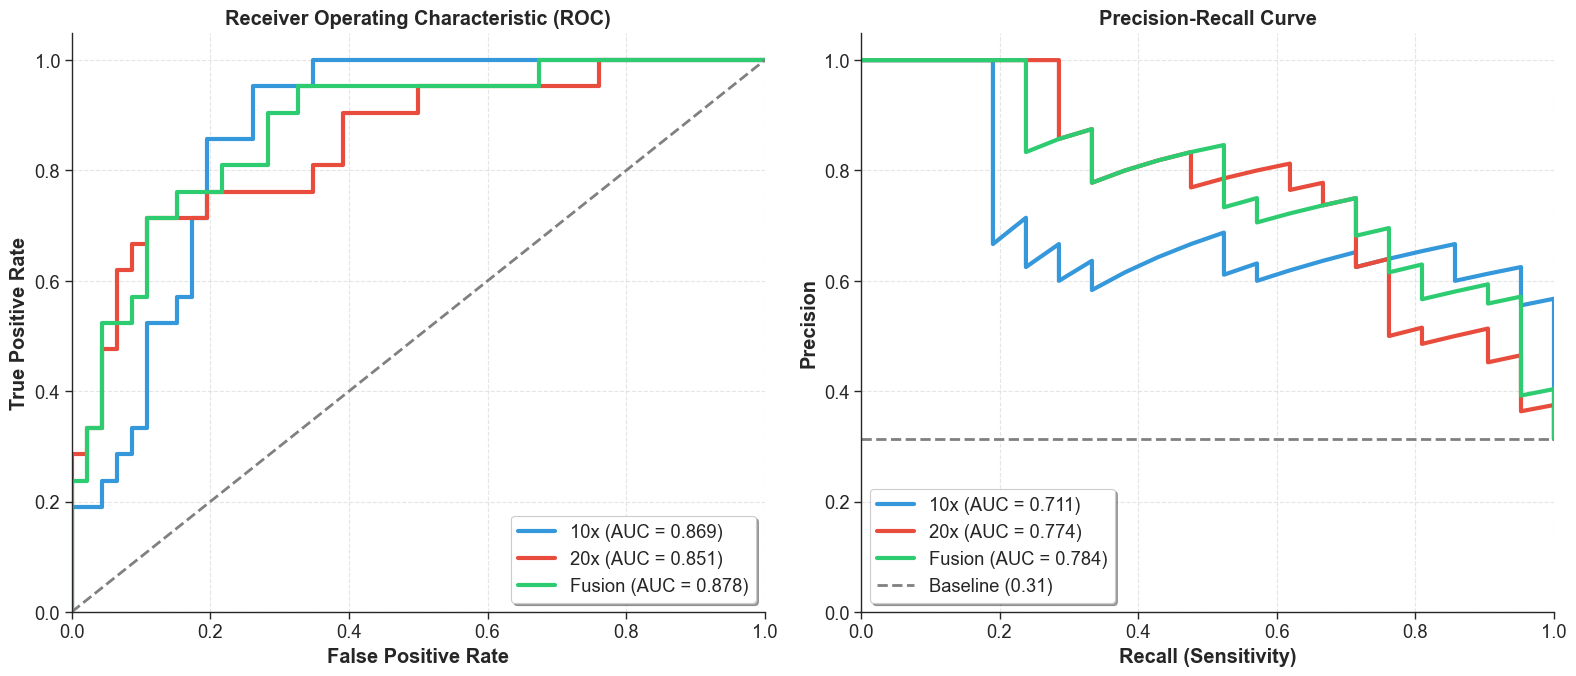

In [3]:
# Cell 3 - ROC and PR Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- Plot 1: ROC Curve ---
for name, probs, color in zip(['10x', '20x', 'Fusion'], 
                              [probs_x10, probs_x20, probs_fused], 
                              [COLORS['x10'], COLORS['x20'], COLORS['fused']]):
    
    fpr, tpr, _ = roc_curve(y_true, probs)
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, color=color, lw=3, label=f'{name} (AUC = {roc_auc:.3f})')

ax1.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate', fontweight='bold')
ax1.set_ylabel('True Positive Rate', fontweight='bold')
ax1.set_title('Receiver Operating Characteristic (ROC)', fontweight='bold')
ax1.legend(loc="lower right", frameon=True, shadow=True)
ax1.grid(True, linestyle='--', alpha=0.5)

# --- Plot 2: Precision-Recall Curve ---
# PR curves are critical for imbalanced medical data
for name, probs, color in zip(['10x', '20x', 'Fusion'], 
                              [probs_x10, probs_x20, probs_fused], 
                              [COLORS['x10'], COLORS['x20'], COLORS['fused']]):
    
    precision, recall, _ = precision_recall_curve(y_true, probs)
    pr_auc = average_precision_score(y_true, probs)
    ax2.plot(recall, precision, color=color, lw=3, label=f'{name} (AUC = {pr_auc:.3f})')

# Baseline for PR curve is the ratio of positive cases
baseline = len(y_true[y_true==1]) / len(y_true)
ax2.plot([0, 1], [baseline, baseline], color='gray', lw=2, linestyle='--', label=f'Baseline ({baseline:.2f})')

ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall (Sensitivity)', fontweight='bold')
ax2.set_ylabel('Precision', fontweight='bold')
ax2.set_title('Precision-Recall Curve', fontweight='bold')
ax2.legend(loc="lower left", frameon=True, shadow=True)
ax2.grid(True, linestyle='--', alpha=0.5)

sns.despine()
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'Fig2_ROC_PR_Curves.png', dpi=DPI, bbox_inches='tight')
plt.show()

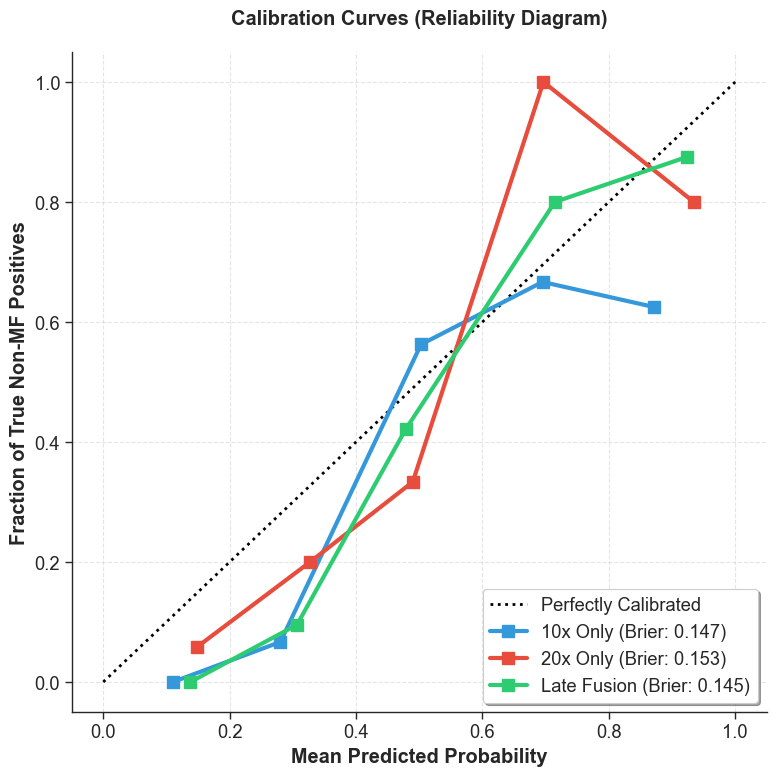

In [4]:
# Cell 4 - Reliability Diagram (Calibration Curve)
fig, ax = plt.subplots(figsize=(8, 8))

# Plot the perfectly calibrated line
ax.plot([0, 1], [0, 1], "k:", label="Perfectly Calibrated", lw=2)

for name, probs, color in zip(['10x Only', '20x Only', 'Late Fusion'], 
                              [probs_x10, probs_x20, probs_fused], 
                              [COLORS['x10'], COLORS['x20'], COLORS['fused']]):
    
    # Calculate calibration curve
    prob_true, prob_pred = calibration_curve(y_true, probs, n_bins=5, strategy='uniform')
    brier = brier_score_loss(y_true, probs)
    
    # Plot
    ax.plot(prob_pred, prob_true, "s-", color=color, lw=3, markersize=8,
             label=f"{name} (Brier: {brier:.3f})")

ax.set_ylabel("Fraction of True Non-MF Positives", fontweight='bold')
ax.set_xlabel("Mean Predicted Probability", fontweight='bold')
ax.set_title('Calibration Curves (Reliability Diagram)', fontweight='bold', pad=20)
ax.set_xlim([-0.05, 1.05])
ax.set_ylim([-0.05, 1.05])
ax.legend(loc="lower right", frameon=True, shadow=True)
ax.grid(True, linestyle='--', alpha=0.5)

sns.despine()
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'Fig3_Calibration_Plot.png', dpi=DPI, bbox_inches='tight')
plt.show()

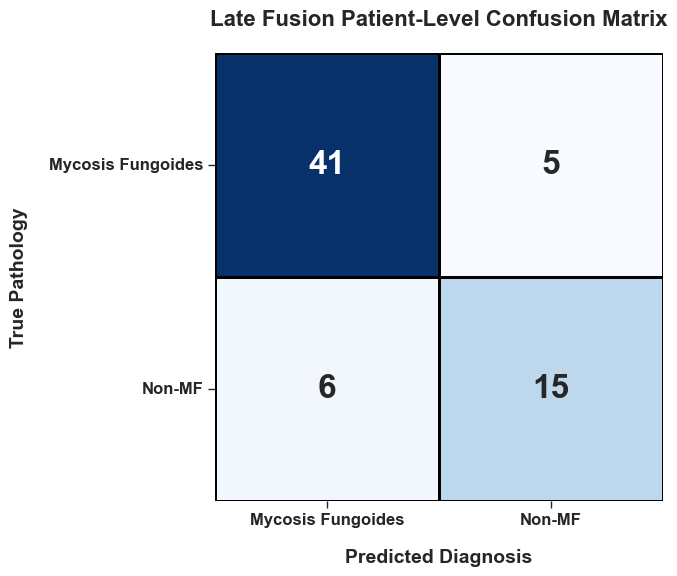

In [6]:
# Cell 5 - Confusion Matrix Heatmap
fig, ax = plt.subplots(figsize=(7, 6))

# Get discrete predictions from the fused probabilities
preds_fused = (probs_fused > 0.5).astype(int)
cm = confusion_matrix(y_true, preds_fused)

# Create heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            cbar=False, square=True, annot_kws={"size": 24, "weight": "bold"},
            linewidths=2, linecolor='black')

# Labels
ax.set_xlabel('Predicted Diagnosis', fontweight='bold', fontsize=14, labelpad=15)
ax.set_ylabel('True Pathology', fontweight='bold', fontsize=14, labelpad=15)
ax.set_title('Late Fusion Patient-Level Confusion Matrix', fontweight='bold', fontsize=16, pad=20)

# Ticks
tick_marks = np.arange(2) + 0.5
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(['Mycosis Fungoides', 'Non-MF'], fontsize=12, fontweight='bold')
ax.set_yticklabels(['Mycosis Fungoides', 'Non-MF'], fontsize=12, fontweight='bold', rotation=0)

plt.tight_layout()
plt.savefig(RESULTS_PATH / 'Fig4_Confusion_Matrix.png', dpi=DPI, bbox_inches='tight')
plt.show()